In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
Main.include("..\\anomalous dim\\non-cusp\\integration.jl")

<PyCall.jlwrap η_test>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


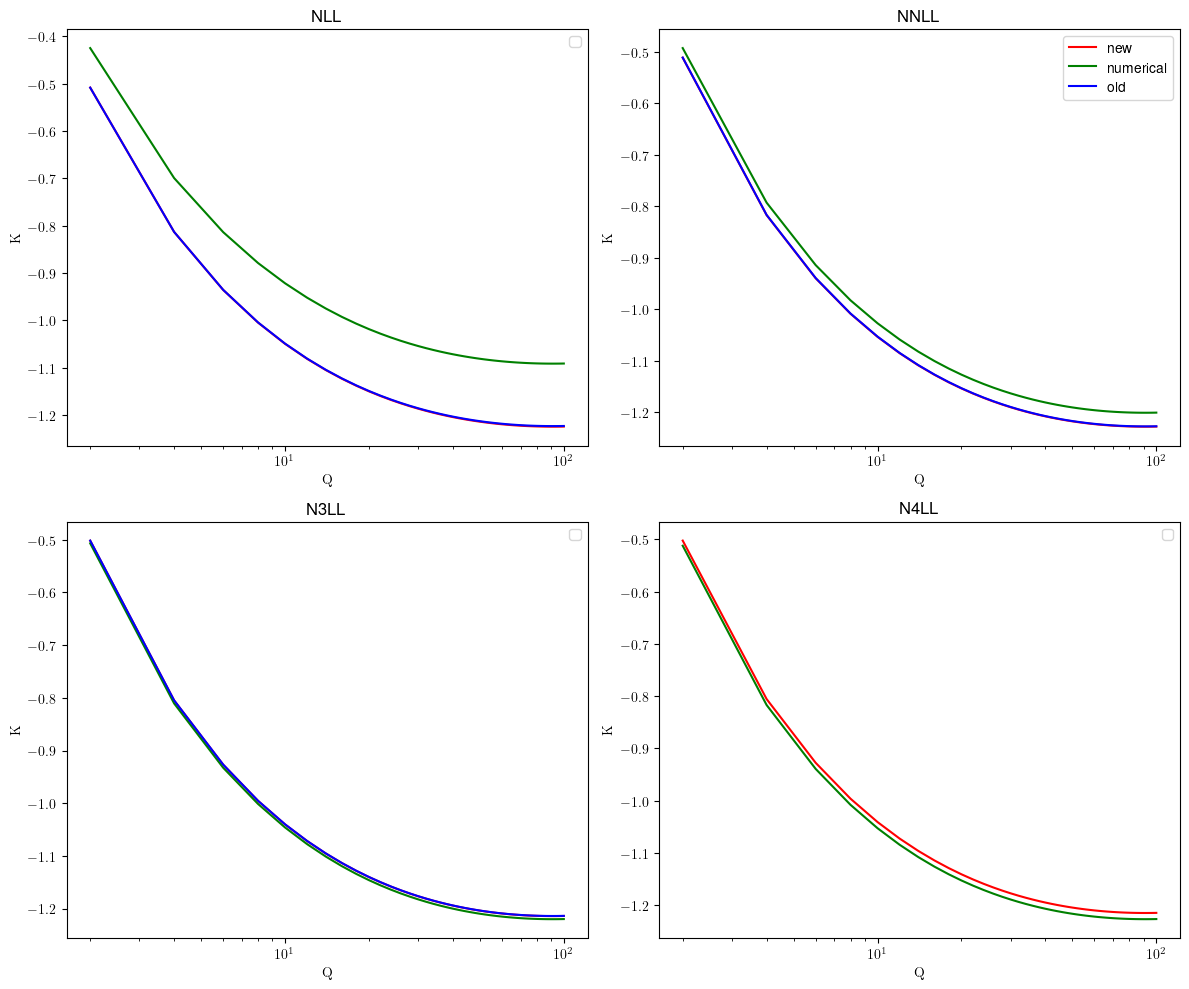

In [34]:
Q_list = np.linspace(2.0,100.0,num=50)
K_1 = np.zeros(len(Q_list))
K_2 = np.zeros(len(Q_list))
K_3 = np.zeros(len(Q_list))
K_4 = np.zeros(len(Q_list))

K_1n = np.zeros(len(Q_list))
K_2n = np.zeros(len(Q_list))
K_3n = np.zeros(len(Q_list))
K_4n = np.zeros(len(Q_list))

K_1o = np.zeros(len(Q_list))
K_2o = np.zeros(len(Q_list))
K_3o = np.zeros(len(Q_list))
K_4o = np.zeros(len(Q_list))

for index, value in enumerate(Q_list):
    K_1[index] = Main.KΓ_integral(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=1, nf=5)
    K_2[index] = Main.KΓ_integral(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=2, nf=5)
    K_3[index] = Main.KΓ_integral(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    K_4[index] = Main.KΓ_integral(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=4, nf=5)

    K_1n[index] = Main.KΓ_test(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=1, nf=5)
    K_2n[index] = Main.KΓ_test(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=2, nf=5)
    K_3n[index] = Main.KΓ_test(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    K_4n[index] = Main.KΓ_test(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=4, nf=5)

    K_1o[index] = Main.KΓ_integral_old(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=1, nf=5)
    K_2o[index] = Main.KΓ_integral_old(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=2, nf=5)
    K_3o[index] = Main.KΓ_integral_old(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    #K_4o[index] = Main.KΓ_integral_old(μi=1.0, μf=value, scale=91.2, αs_ini=0.118, μ_ini=91.2, order=4, nf=5)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10)) 

ax1.plot(Q_list, K_1, color="red")
ax1.plot(Q_list, K_1n, color="green")
ax1.plot(Q_list, K_1o, color="blue")
ax1.set_title("NLL")

ax2.plot(Q_list, K_2, color="red", label="new")
ax2.plot(Q_list, K_2n, color="green", label="numerical")
ax2.plot(Q_list, K_2o, color="blue", label="old")
ax2.set_title("NNLL")

ax3.plot(Q_list, K_3, color="red")
ax3.plot(Q_list, K_3n, color="green")
ax3.plot(Q_list, K_3o, color="blue")
ax3.set_title("N3LL")

ax4.plot(Q_list, K_4, color="red")
ax4.plot(Q_list, K_4n, color="green")
ax4.set_title("N4LL")

ax1.set_xlabel(r"\rm Q")
ax1.set_ylabel(r"\rm K")
ax1.set_xscale('log') 
ax1.legend()

ax2.set_xlabel(r"\rm Q")
ax2.set_ylabel(r"\rm K")
ax2.set_xscale('log')
ax2.legend()

ax3.set_xlabel(r"\rm Q")
ax3.set_ylabel(r"\rm K")
ax3.set_xscale('log') 
ax3.legend()

ax4.set_xlabel(r"\rm Q")
ax4.set_ylabel(r"\rm K")
ax4.set_xscale('log')
ax4.legend()

plt.tight_layout()  
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


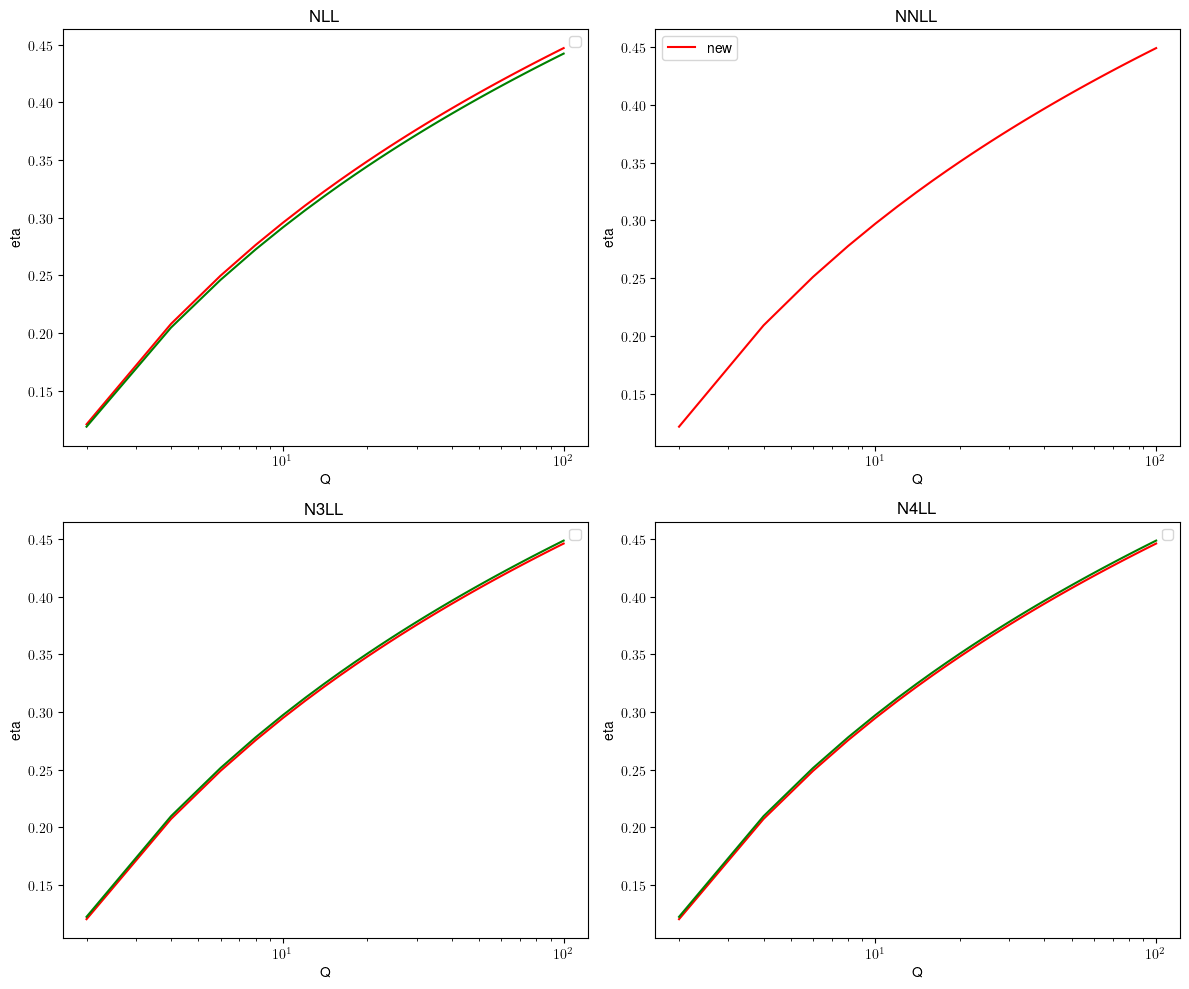

In [4]:
Q_list = np.linspace(2.0,100.0,num=50)
η_1 = np.zeros(len(Q_list))
η_2 = np.zeros(len(Q_list))
η_3 = np.zeros(len(Q_list))
η_4 = np.zeros(len(Q_list))

η_1n = np.zeros(len(Q_list))
η_2n = np.zeros(len(Q_list))
η_3n = np.zeros(len(Q_list))
η_4n = np.zeros(len(Q_list))

F0=Main.Γ0_func(5)
F1=Main.Γ1_func(5) 
F2=Main.Γ2_func(5) 
F3=Main.Γ3_func(5)
F4=Main.Γ4_func(5)

for index, value in enumerate(Q_list):
    η_1[index] = Main.η_integral(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=1, nf=5,
                                 F0=F0,F1=F1,F2=F2,F3=F3,F4=F4)
    η_2[index] = Main.η_integral(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=2, nf=5,
                                 F0=F0,F1=F1,F2=F2,F3=F3,F4=F4)
    η_3[index] = Main.η_integral(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=3, nf=5,
                                 F0=F0,F1=F1,F2=F2,F3=F3,F4=F4)
    η_4[index] = Main.η_integral(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=4, nf=5,
                                 F0=F0,F1=F1,F2=F2,F3=F3,F4=F4)

    η_1n[index] = Main.η_test(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=1, nf=5)
    η_2n[index] = Main.η_test(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=2, nf=5)
    η_3n[index] = Main.η_test(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    η_4n[index] = Main.η_test(μi=1.0, μf=value, αs_ini=0.118, μ_ini=91.2, order=4, nf=5)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10)) 

ax1.plot(Q_list, η_1, color="red")
ax1.plot(Q_list, η_1n, color="green")
ax1.set_title("NLL")

ax2.plot(Q_list, η_2, color="red", label="new")
#ax2.plot(Q_list, η_2n, color="green", label="numerical")
ax2.set_title("NNLL")

ax3.plot(Q_list, η_3, color="red")
ax3.plot(Q_list, η_3n, color="green")
ax3.set_title("N3LL")

ax4.plot(Q_list, η_4, color="red")
ax4.plot(Q_list, η_4n, color="green")
ax4.set_title("N4LL")

ax1.set_xlabel("Q")
ax1.set_ylabel("eta")
ax1.set_xscale('log') 
ax1.legend()

ax2.set_xlabel("Q")
ax2.set_ylabel("eta")
ax2.set_xscale('log')
ax2.legend()

ax3.set_xlabel("Q")
ax3.set_ylabel("eta")
ax3.set_xscale('log') 
ax3.legend()

ax4.set_xlabel("Q")
ax4.set_ylabel("eta")
ax4.set_xscale('log')
ax4.legend()

plt.tight_layout()  
plt.show()